# Explore a sham-feeding `*_lickprocessed.pkl`

A complete tour of *everything* in a raw sham-feeding pickle, before NWB conversion. Set `PKL` below to the file to explore.

The pickle is a **2-tuple of dicts, one per recording side / hemisphere**. Each side's identity is read from its `Full_side_name` (e.g. `COM3_Left_mNacSh`). Photometry channels: `analog_1` = 470 nm gACh4h, `analog_2` = 565 nm rDA3m, `analog_3` = 405 nm gACh4h reference. The region↔side mapping varies between sessions, so always read it from the data. Every section below loops over **both sides**.

Run with the `jdb_to_nwb` conda env.

In [21]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PKL = "IM1923_Trial-SF5-Sucrose_11-06-2025_lickprocessed.pkl"

# Per analog channel: (pickle key, excitation wavelength nm, sensor/role, plot color)
CHANNELS = [
    ("analog_1", 470, "gACh4h",     "#2CA02C"),
    ("analog_2", 565, "rDA3m",      "#D62728"),
    ("analog_3", 405, "gACh4h ref", "#8FBF8F"),
]
# The lick-burst stats live under this key (ILI-based bursts, 2000 ms gap threshold)
BURST_KEY = "LickBurst_Vars_BurstDefinitionILI_basedThresh2000"

with open(PKL, "rb") as pkl_file:
    data = pickle.load(pkl_file)


def describe(value):
    """One-line type/shape summary of a value."""
    if isinstance(value, np.ndarray):
        return f"ndarray {value.shape} {value.dtype}"
    if isinstance(value, pd.DataFrame):
        return f"DataFrame {value.shape}"
    if isinstance(value, pd.Series):
        return f"Series len={len(value)} ({value.dtype})"
    if isinstance(value, dict):
        return f"dict keys={list(value.keys())}"
    if isinstance(value, (list, tuple)):
        return f"{type(value).__name__} len={len(value)}"
    return f"{type(value).__name__}: {repr(value)[:70]}"


print("top-level:", type(data).__name__, "| n sides:", len(data))
for index, side_data in enumerate(data):
    print(f"  side {index}: {side_data['Full_side_name']} | {len(side_data)} keys | {len(side_data['analog_1'])} samples")

top-level: tuple | n sides: 2
  side 0: COM3_Left_mNacSh | 69 keys | 364042 samples
  side 1: COM4_Right_NacCore | 69 keys | 364047 samples


## 1. Full key inventory (both sides)

Every key with its type and shape/length, one column per side, so nothing is hidden.

In [22]:
pd.set_option("display.max_rows", None, "display.max_colwidth", 90)
# One column per side; each row is a key with its type/shape summary
pd.DataFrame({side_data["Full_side_name"]: {key: describe(value) for key, value in side_data.items()}
              for side_data in data})

,COM3_Left_mNacSh,COM4_Right_NacCore
filename,str: 'IM1923_Trial-SF5-Sucrose_COM3_-2025-11-06-093135.ppd',str: 'IM1923_Trial-SF5-Sucrose_COM4_-2025-11-06-093135.ppd'
analog_1,"ndarray (364042,) float64","ndarray (364047,) float64"
analog_2,"ndarray (364042,) float64","ndarray (364047,) float64"
analog_1_filt,"ndarray (364042,) float64","ndarray (364047,) float64"
analog_2_filt,"ndarray (364042,) float64","ndarray (364047,) float64"
digital_1,"ndarray (364042,) int64","ndarray (364047,) int64"
digital_2,NoneType: None,NoneType: None
pulse_inds_1,"ndarray (3773,) int64","ndarray (3773,) int64"
pulse_inds_2,NoneType: None,NoneType: None
pulse_times_1,"ndarray (3773,) float64","ndarray (3773,) float64"


## 2. Session / animal metadata (scalars)

The non-array fields describing the animal, sides, targets and acquisition settings.

In [23]:
scalar_keys = [
    "filename", "subject_ID", "Full_animalNumber", "Sex", "DOB", "Strain",
    "date_time", "end_time", "Full_side_name", "Left_COM", "Right_COM",
    "Hit_L", "Target_L", "Hit_R", "Target_R", "GramConsumed", "GramInPan",
    "mode", "sampling_rate", "n_analog_signals", "n_digital_signals",
    "LED_current", "volts_per_division", "version",
    "BottleIn_frameNum", "SessionStart_frameNum", "SessionEnd_frameNum",
]
for side_data in data:
    print("=" * 70, "\n", side_data["Full_side_name"])
    for key in scalar_keys:
        print(f"  {key:24s} {side_data.get(key)}")
    print("  Config_Lickdetection:", side_data["Processing_params"]["Config_Lickdetection"])

 COM3_Left_mNacSh
  filename                 IM1923_Trial-SF5-Sucrose_COM3_-2025-11-06-093135.ppd
  subject_ID               IM1923_Trial_SF5-Sucrose_COM3_
  Full_animalNumber        817411A
  Sex                      Male
  DOB                      2025-04-29 00:00:00
  Strain                   WT (PV-)
  date_time                2025-11-06 09:31:35.090000
  end_time                 2025-11-06T10:42:08.163
  Full_side_name           COM3_Left_mNacSh
  Left_COM                 COM3
  Right_COM                COM4
  Hit_L                    mNacSh
  Target_L                 mNacSh
  Hit_R                    NacCore
  Target_R                 NacCore
  GramConsumed             81.82
  GramInPan                80.84000000000003
  mode                     3EX_2EM_pulsed
  sampling_rate            86
  n_analog_signals         3
  n_digital_signals        1
  LED_current              [10, 47]
  volts_per_division       [0.00010122, 0.00010122]
  version                  1.0
  BottleIn_frame

## 3. Photometry signals

`analog_1/2/3` are the raw channels (volts), `*_filt` are pyPhotometry-filtered, `analogN_hampel` are outlier-cleaned. `time` is in ms.

COM3_Left_mNacSh: 86 Hz | 364042 samples | 70.6 min
   analog_1 (470 nm, gACh4h     ): mean=1.5838 V  min=1.5020  max=1.7305
   analog_2 (565 nm, rDA3m      ): mean=0.8030 V  min=0.6847  max=1.1180
   analog_3 (405 nm, gACh4h ref ): mean=1.4971 V  min=1.4301  max=1.7828
COM4_Right_NacCore: 86 Hz | 364047 samples | 70.6 min
   analog_1 (470 nm, gACh4h     ): mean=0.9780 V  min=0.9302  max=1.0421
   analog_2 (565 nm, rDA3m      ): mean=0.7290 V  min=0.6354  max=0.9829
   analog_3 (405 nm, gACh4h ref ): mean=1.1412 V  min=1.0333  max=1.3061


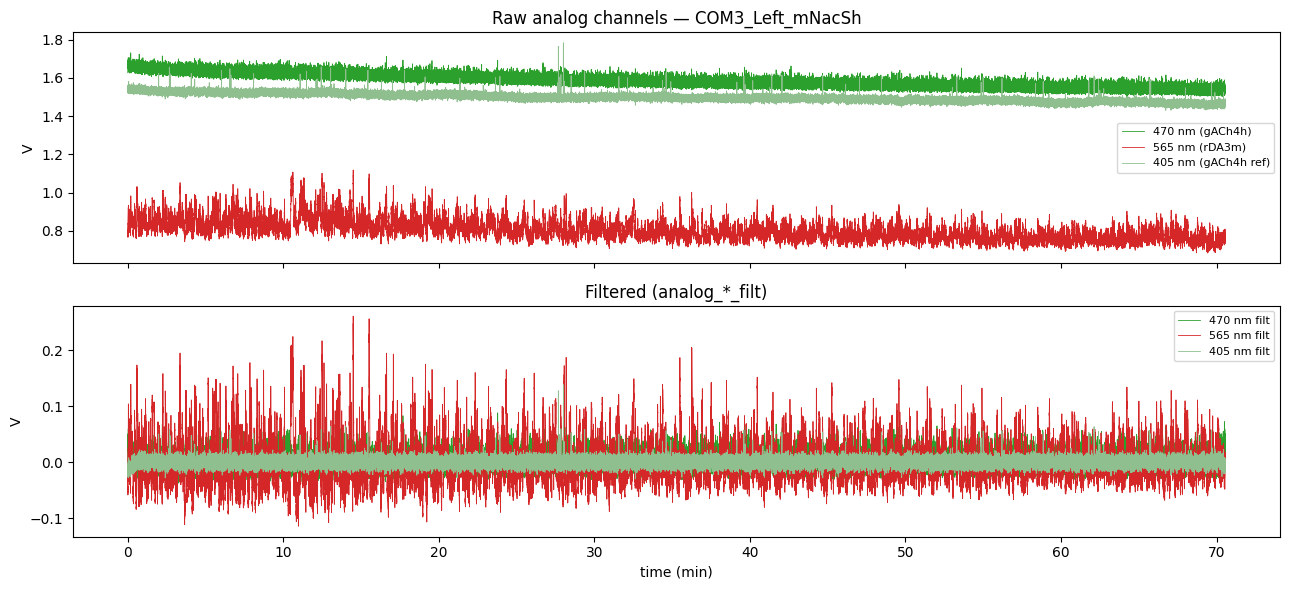

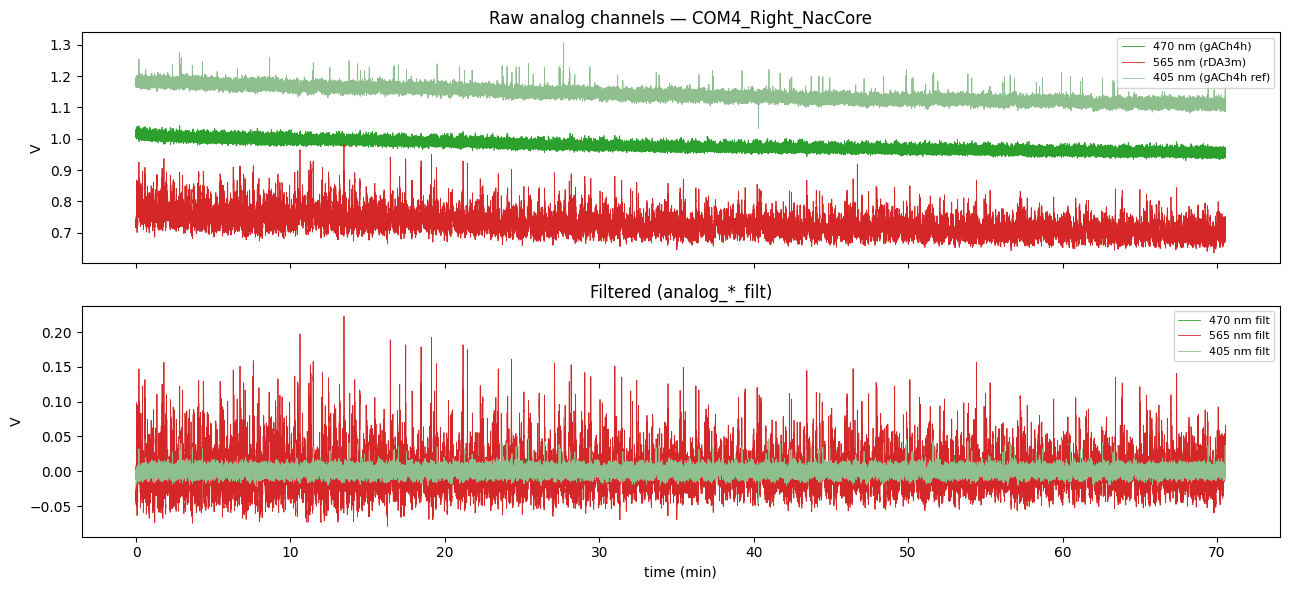

In [24]:
for side_data in data:
    fs = side_data["sampling_rate"]
    time_min = side_data["time"] / 1000 / 60          # ms -> minutes (photometry stream clock)
    print(f"{side_data['Full_side_name']}: {fs} Hz | {len(side_data['analog_1'])} samples | {time_min[-1]:.1f} min")
    for analog_key, wavelength, sensor, _color in CHANNELS:
        channel = side_data[analog_key]
        print(f"   {analog_key} ({wavelength} nm, {sensor:11s}): "
              f"mean={channel.mean():.4f} V  min={channel.min():.4f}  max={channel.max():.4f}")

    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    for analog_key, wavelength, sensor, color in CHANNELS:
        ax[0].plot(time_min, side_data[analog_key], color=color, lw=0.6, label=f"{wavelength} nm ({sensor})")
        ax[1].plot(time_min, side_data[f"{analog_key}_filt"], color=color, lw=0.6, label=f"{wavelength} nm filt")
    ax[0].set_title(f"Raw analog channels — {side_data['Full_side_name']}"); ax[0].set_ylabel("V"); ax[0].legend(fontsize=8)
    ax[1].set_title("Filtered (analog_*_filt)"); ax[1].set_ylabel("V"); ax[1].set_xlabel("time (min)"); ax[1].legend(fontsize=8)
    fig.tight_layout()

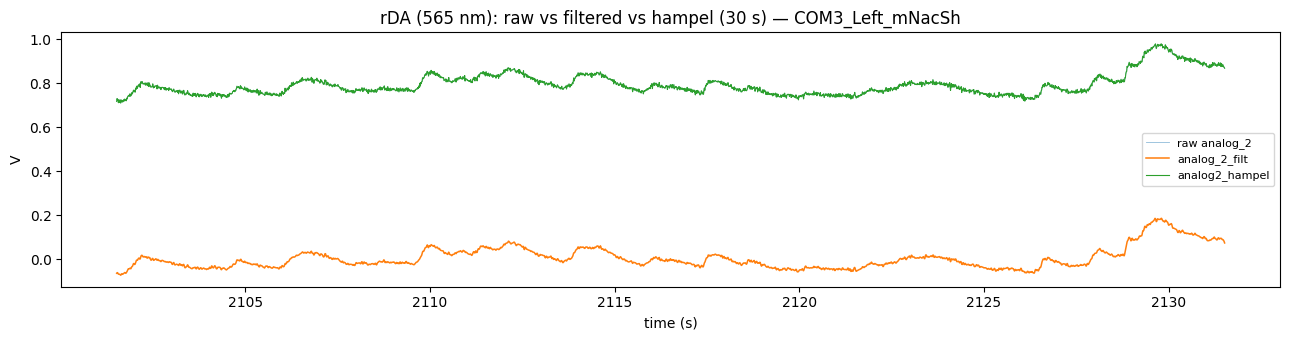

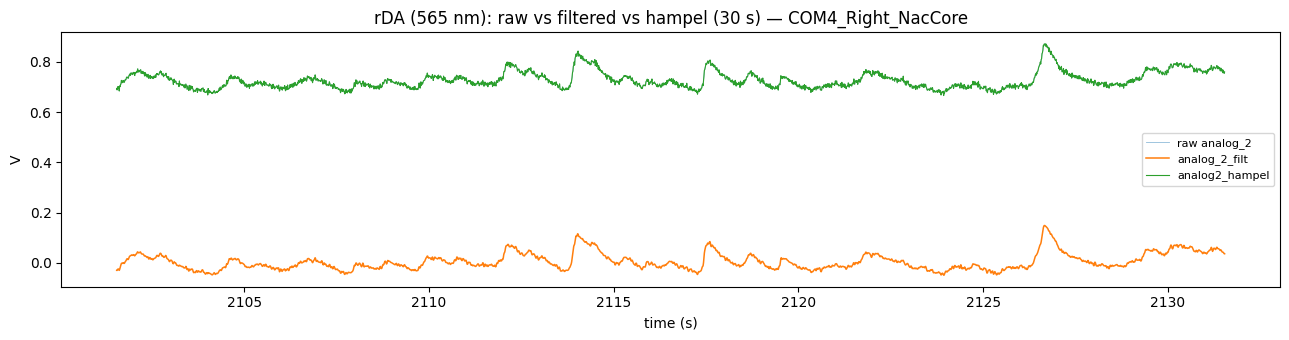

In [25]:
# Raw vs pyPhotometry-filtered vs Hampel-cleaned, on rDA (analog_2), 30 s window centered mid-session
for side_data in data:
    fs = side_data["sampling_rate"]
    time_s = side_data["time"] / 1000
    center_idx = len(side_data["analog_2"]) // 2
    window = slice(center_idx - int(15 * fs), center_idx + int(15 * fs))
    fig, ax = plt.subplots(figsize=(13, 3.5))
    ax.plot(time_s[window], side_data["analog_2"][window], lw=0.6, alpha=0.5, label="raw analog_2")
    ax.plot(time_s[window], side_data["analog_2_filt"][window], lw=1.1, label="analog_2_filt")
    ax.plot(time_s[window], side_data["analog2_hampel"][window], lw=0.8, label="analog2_hampel")
    ax.set_title(f"rDA (565 nm): raw vs filtered vs hampel (30 s) — {side_data['Full_side_name']}")
    ax.set_xlabel("time (s)"); ax.set_ylabel("V"); ax.legend(fontsize=8)
    fig.tight_layout()

## 4. Sync signals (rsync)

`digital_1` is the rsync TTL; rising edges are at `pulse_inds_1` (samples) / `pulse_times_1` (ms). `Rsync_aligned-from-licks` and `rSync_interpolated_from_video` are the rsync reconstructed from the lick and video streams, used to align those streams to photometry.

COM3_Left_mNacSh | digital_1 high: 81257 | n pulses: 3773 | Rsync_aligned-from-licks: (364042,) | rSync_interpolated_from_video: (364042,)
COM4_Right_NacCore | digital_1 high: 81274 | n pulses: 3773 | Rsync_aligned-from-licks: (364047,) | rSync_interpolated_from_video: (364047,)


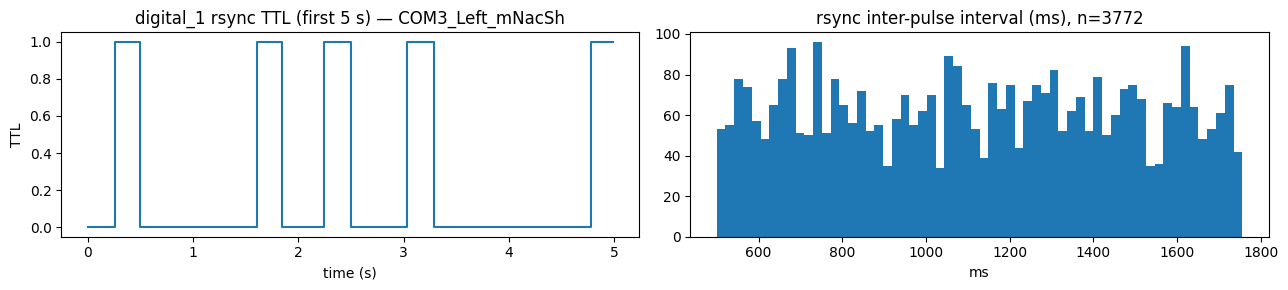

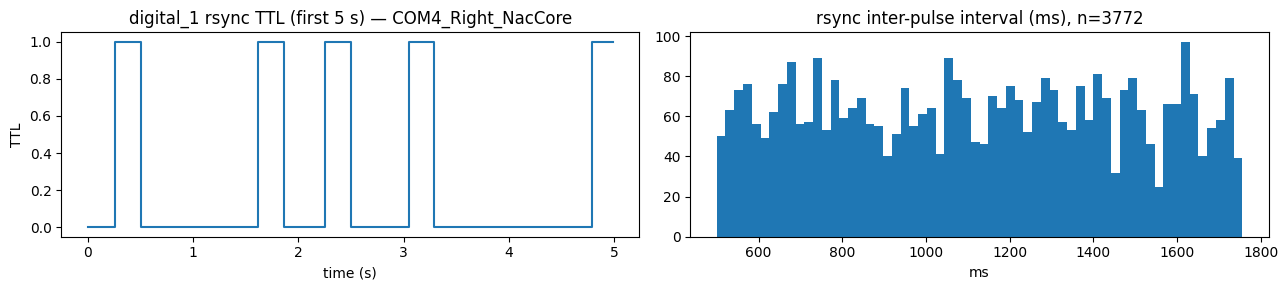

In [26]:
for side_data in data:
    fs = side_data["sampling_rate"]
    print(side_data["Full_side_name"],
          "| digital_1 high:", int(side_data["digital_1"].sum()),
          "| n pulses:", len(side_data["pulse_inds_1"]),
          "| Rsync_aligned-from-licks:", side_data["Rsync_aligned-from-licks"].shape,
          "| rSync_interpolated_from_video:", side_data["rSync_interpolated_from_video"].shape)

    inter_pulse_ms = np.diff(side_data["pulse_times_1"])   # rsync inter-pulse intervals (ms)
    first_5s = int(5 * fs)
    fig, ax = plt.subplots(1, 2, figsize=(13, 3))
    ax[0].step(side_data["time"][:first_5s] / 1000, side_data["digital_1"][:first_5s], where="post")
    ax[0].set_title(f"digital_1 rsync TTL (first 5 s) — {side_data['Full_side_name']}")
    ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("TTL")
    ax[1].hist(inter_pulse_ms, bins=60)
    ax[1].set_title(f"rsync inter-pulse interval (ms), n={len(inter_pulse_ms)}"); ax[1].set_xlabel("ms")
    fig.tight_layout()

## 5. Lick detection

`LickBinary_2.3` is the per-sample binary lick at the photometry clock. `RawLickData` is the full per-video-frame acquisition table the licks were derived from.

In [27]:
for side_data in data:
    lick_binary = side_data["LickBinary_2.3"]
    raw_lick_df = side_data["RawLickData"]
    print(f"{side_data['Full_side_name']}: LickBinary unique {np.unique(lick_binary[~np.isnan(lick_binary)])} | "
          f"n licks(1s) {int(np.nansum(lick_binary))} | n NaN {int(np.isnan(lick_binary).sum())} | "
          f"RawLickData {raw_lick_df.shape}")

# Structural preview (columns are the same for both sides)
print("\nRawLickData columns:", list(data[0]["RawLickData"].columns))
data[0]["RawLickData"].head()

COM3_Left_mNacSh: LickBinary unique [0. 1.] | n licks(1s) 22301 | n NaN 3189 | RawLickData (380625, 11)
COM4_Right_NacCore: LickBinary unique [0. 1.] | n licks(1s) 22262 | n NaN 3190 | RawLickData (380625, 11)

RawLickData columns: ['AbsTime', 'RelTime', 'LixPos', 'AnalogLick', 'rSync', 'VDiff', 'Abs_time2', 'BinLick', 'ms_since_midnight', 'True_Time_ms', 'True_Absolute_Time']


,AbsTime,RelTime,LixPos,AnalogLick,rSync,VDiff,Abs_time2,BinLick,ms_since_midnight,True_Time_ms,True_Absolute_Time
0,2025-11-06 09:32:03.679188,11.0,0.0,0.767351,0.0,NaN,2025-11-06 09:32:03.690188,0,34323690,34323584.0,2025-11-06 09:32:03.584
1,2025-11-06 09:32:03.680188,22.0,0.0,0.689150,0.0,NaN,2025-11-06 09:32:03.701188,0,34323701,34323595.0,2025-11-06 09:32:03.595
2,2025-11-06 09:32:03.680188,33.0,0.0,0.000000,0.0,NaN,2025-11-06 09:32:03.712188,0,34323712,34323606.0,2025-11-06 09:32:03.606
3,2025-11-06 09:32:03.681187,44.0,0.0,0.742913,0.0,NaN,2025-11-06 09:32:03.723188,0,34323723,34323617.0,2025-11-06 09:32:03.617
4,2025-11-06 09:32:03.681187,55.0,0.0,0.000000,0.0,NaN,2025-11-06 09:32:03.734188,0,34323734,34323628.0,2025-11-06 09:32:03.628


COM3_Left_mNacSh numeric summary:
                            min           max          mean
RelTime            1.100000e+01  4.199999e+06  2.100005e+06
LixPos             0.000000e+00  1.000000e+00  4.285714e-01
AnalogLick         0.000000e+00  5.000000e+00  1.204048e+00
rSync              0.000000e+00  1.000000e+00  2.231330e-01
VDiff             -4.897361e+00  4.936461e+00 -3.424298e-08
BinLick            0.000000e+00  1.000000e+00  6.179573e-02
ms_since_midnight  3.432369e+07  3.852368e+07  3.642368e+07
True_Time_ms       3.432358e+07  3.851952e+07  3.642155e+07 

COM4_Right_NacCore numeric summary:
                            min           max          mean
RelTime            1.100000e+01  4.199999e+06  2.100005e+06
LixPos             0.000000e+00  1.000000e+00  4.285714e-01
AnalogLick         0.000000e+00  5.000000e+00  1.204048e+00
rSync              0.000000e+00  1.000000e+00  2.231330e-01
VDiff             -4.897361e+00  4.936461e+00 -3.424298e-08
BinLick            0.000000e

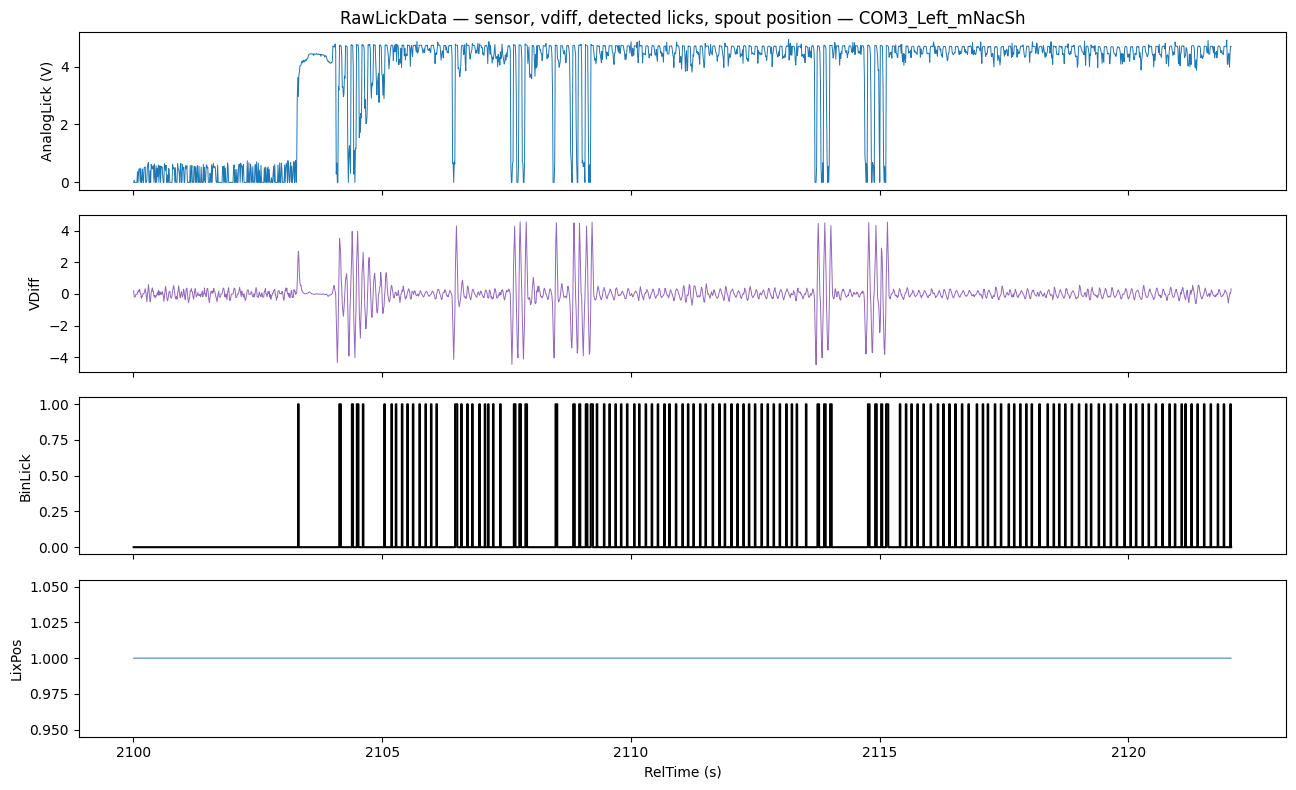

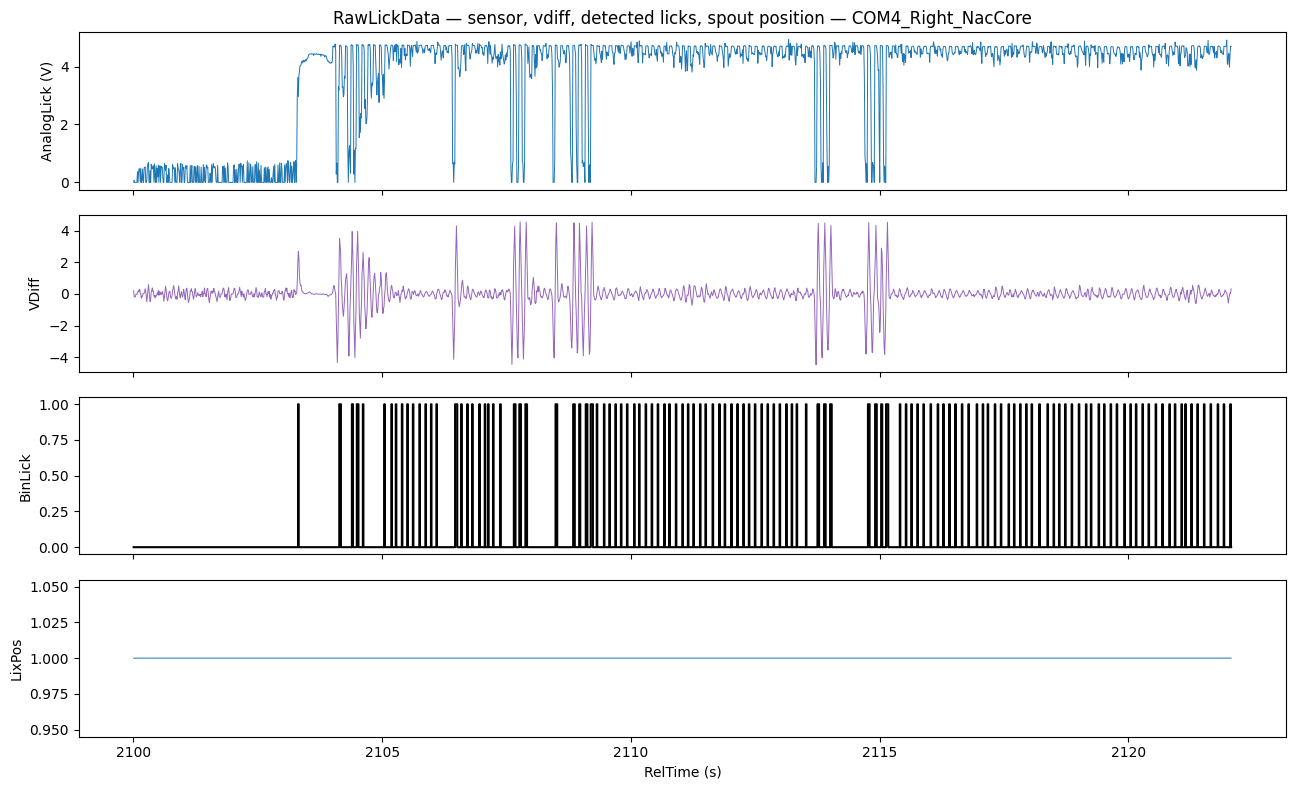

In [28]:
# RawLickData column meanings:
#   AbsTime / Abs_time2 / True_Absolute_Time : wall-clock timestamps (raw, +offset, rsync-corrected)
#   RelTime : ms since acquisition start    ms_since_midnight / True_Time_ms : clock-based time
#   LixPos  : spout/lixit position           AnalogLick : raw lick-sensor voltage
#   VDiff   : voltage difference (lick-detection feature)   BinLick : detected lick (0/1)
#   rSync   : rsync TTL on the lick stream
for side_data in data:
    raw_lick_df = side_data["RawLickData"]
    print(side_data["Full_side_name"], "numeric summary:")
    print(raw_lick_df.select_dtypes("number").describe().T[["min", "max", "mean"]], "\n")

    middle = len(raw_lick_df) // 2                  # a window in the middle of the table
    window_df = raw_lick_df.iloc[middle:middle + 2000]
    fig, ax = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
    ax[0].plot(window_df["RelTime"] / 1000, window_df["AnalogLick"], lw=0.7); ax[0].set_ylabel("AnalogLick (V)")
    ax[1].plot(window_df["RelTime"] / 1000, window_df["VDiff"], lw=0.7, color="tab:purple"); ax[1].set_ylabel("VDiff")
    ax[2].step(window_df["RelTime"] / 1000, window_df["BinLick"], where="mid", color="k"); ax[2].set_ylabel("BinLick")
    ax[3].plot(window_df["RelTime"] / 1000, window_df["LixPos"], lw=0.7, color="tab:blue"); ax[3].set_ylabel("LixPos")
    ax[3].set_xlabel("RelTime (s)")
    ax[0].set_title(f"RawLickData — sensor, vdiff, detected licks, spout position — {side_data['Full_side_name']}")
    fig.tight_layout()

## 6. Lick bursts

`LickBurst_Vars_BurstDefinitionILI_basedThresh2000` — bursts defined by inter-lick intervals with a 2000 ms gap threshold. Contains per-lick, per-burst and binned-rate arrays, plus the per-sample burst labeling.

In [29]:
for side_data in data:
    burst_vars = side_data[BURST_KEY]
    print(f"{side_data['Full_side_name']}: NumLicks={burst_vars['NumLicks']}  NumBursts={burst_vars['NumBursts']}  "
          f"BurstThreshold={burst_vars['BurstThreshold_ms']} ms  "
          f"mean licks/burst={np.mean(burst_vars['Avg_LicksPerBurst']):.0f}")

# field listing (same structure for both sides)
print("\nfields:")
for key, value in data[0][BURST_KEY].items():
    print(f"  {key:24s} {describe(value)}")

COM3_Left_mNacSh: NumLicks=9245  NumBursts=74  BurstThreshold=2000 ms  mean licks/burst=301
COM4_Right_NacCore: NumLicks=9246  NumBursts=74  BurstThreshold=2000 ms  mean licks/burst=301

fields:
  NumLicks                 int: 9245
  CumLicks                 ndarray (358273,) int64
  LickDurations_ms         ndarray (9245,) float64
  InterlickInterval_ms     ndarray (9244,) float64
  Lickrate_1s              ndarray (4166,) float64
  Lickrate_1m              ndarray (70,) float64
  Lickrate_5m              list len=14
  ILI_startend_ms          ndarray (9244,) float64
  BurstThreshold_ms        int: 2000
  NumBursts                int: 74
  Full_BurstDur            list len=74
  Lick_BurstDur            list len=74
  Avg_LicksPerBurst        list len=74
  Labeled_BurstLick        ndarray (358273, 2) float64
  ILI_withinBursts         list len=74
  ILI_betweenBursts        list len=73


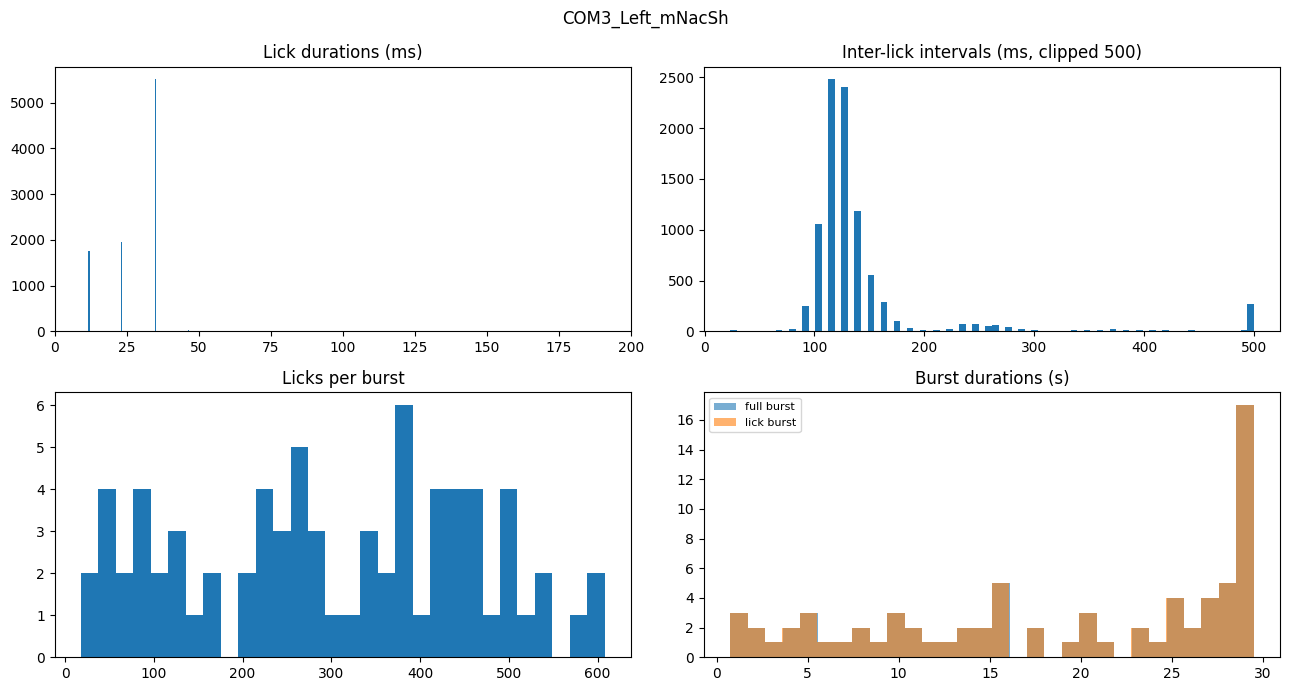

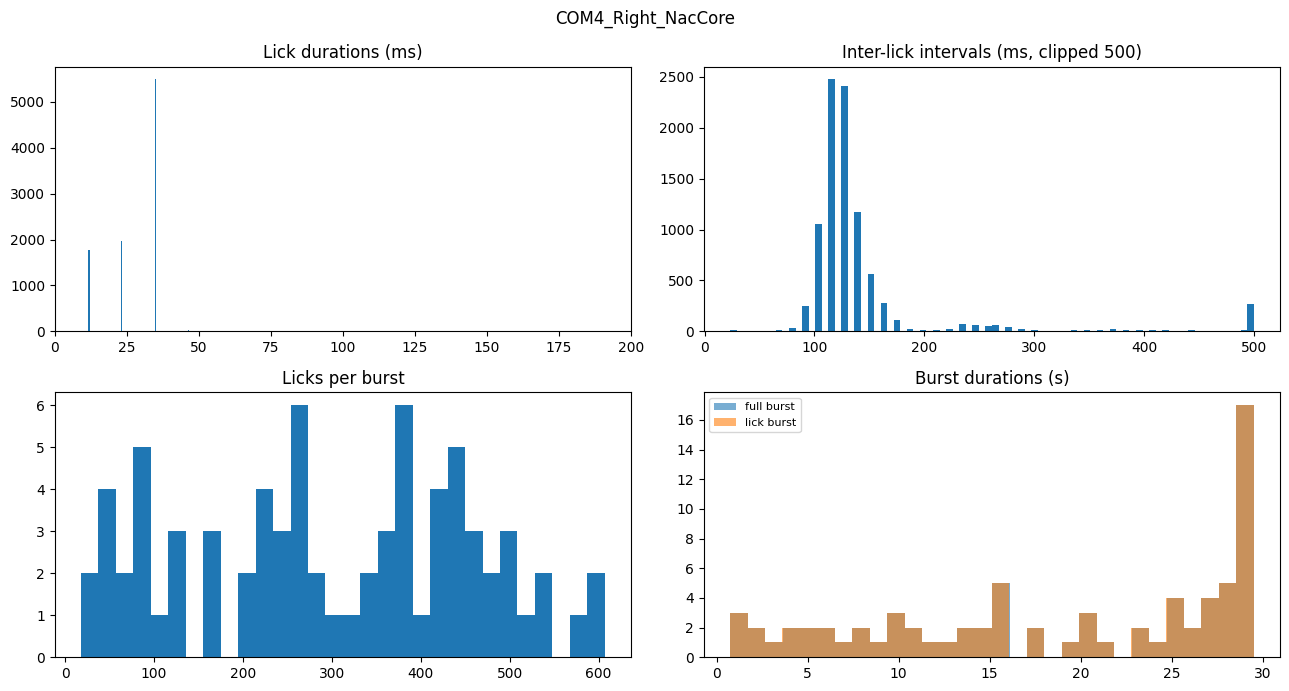

In [30]:
for side_data in data:
    burst_vars = side_data[BURST_KEY]
    fig, ax = plt.subplots(2, 2, figsize=(13, 7))
    ax[0, 0].hist(burst_vars["LickDurations_ms"], bins=80); ax[0, 0].set_title("Lick durations (ms)"); ax[0, 0].set_xlim(0, 200)
    ax[0, 1].hist(np.clip(burst_vars["InterlickInterval_ms"], 0, 500), bins=80); ax[0, 1].set_title("Inter-lick intervals (ms, clipped 500)")
    ax[1, 0].hist(burst_vars["Avg_LicksPerBurst"], bins=30); ax[1, 0].set_title("Licks per burst")
    ax[1, 1].hist(np.array(burst_vars["Full_BurstDur"]) / 1000, bins=30, alpha=0.6, label="full burst")
    ax[1, 1].hist(np.array(burst_vars["Lick_BurstDur"]) / 1000, bins=30, alpha=0.6, label="lick burst")
    ax[1, 1].set_title("Burst durations (s)"); ax[1, 1].legend(fontsize=8)
    fig.suptitle(side_data["Full_side_name"]); fig.tight_layout()

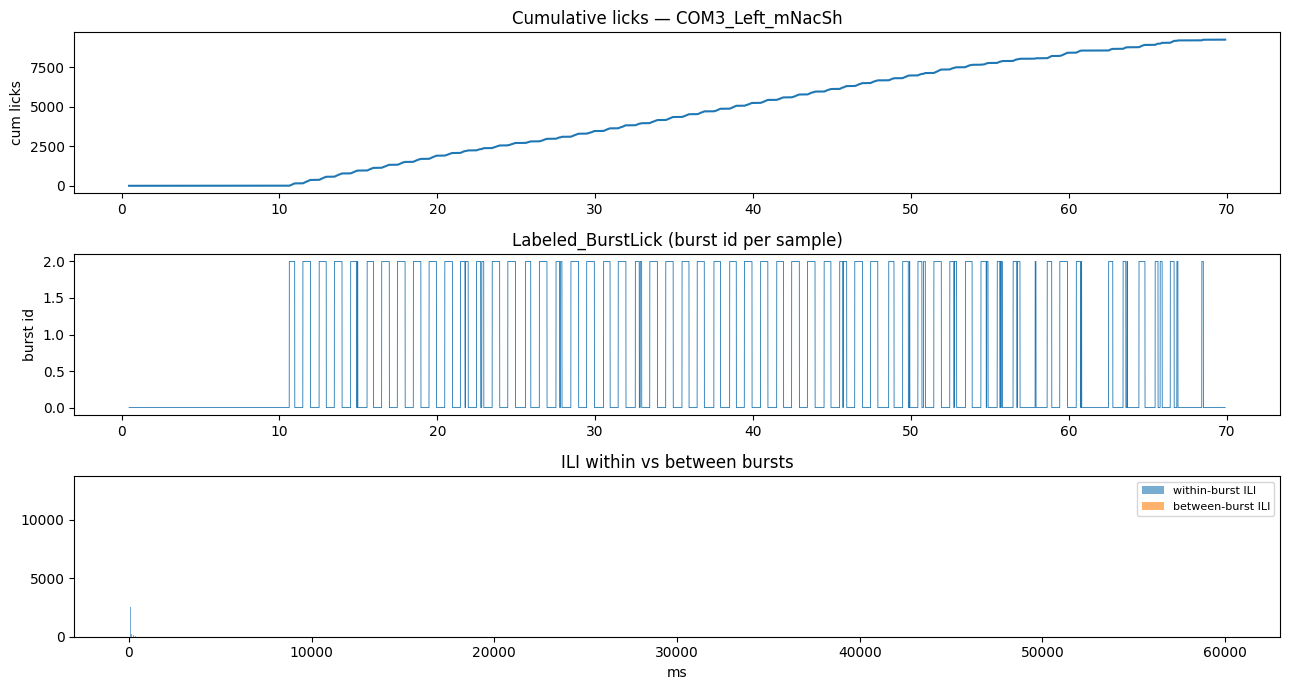

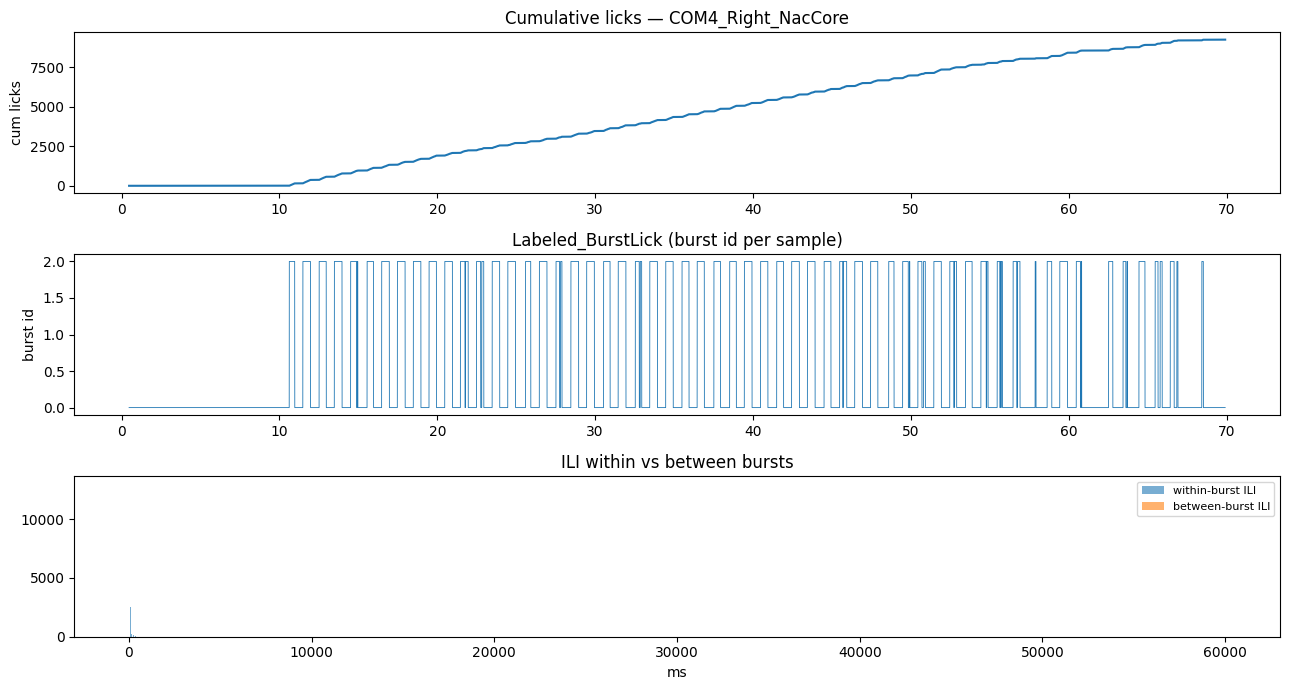

In [31]:
# Per-sample burst labeling (Labeled_BurstLick) and within- vs between-burst ILIs.
# These session-cropped arrays begin at SessionStart_frameNum on the photometry clock.
for side_data in data:
    fs = side_data["sampling_rate"]
    burst_vars = side_data[BURST_KEY]
    labeled_burst_lick = np.asarray(burst_vars["Labeled_BurstLick"])  # cols: (in-burst flag, burst id)
    burst_time_min = (side_data["SessionStart_frameNum"] + np.arange(len(labeled_burst_lick))) / fs / 60
    within_burst_ilis = np.concatenate([np.asarray(x) for x in burst_vars["ILI_withinBursts"] if len(np.asarray(x)) > 0])

    fig, ax = plt.subplots(3, 1, figsize=(13, 7))
    ax[0].plot(burst_time_min, np.asarray(burst_vars["CumLicks"])); ax[0].set_ylabel("cum licks")
    ax[0].set_title(f"Cumulative licks — {side_data['Full_side_name']}")
    ax[1].plot(burst_time_min, labeled_burst_lick[:, 1], lw=0.6); ax[1].set_ylabel("burst id")
    ax[1].set_title("Labeled_BurstLick (burst id per sample)")
    ax[2].hist(np.clip(within_burst_ilis, 0, 1000), bins=60, alpha=0.6, label="within-burst ILI")
    ax[2].hist(np.clip(burst_vars["ILI_betweenBursts"], 0, 60000), bins=60, alpha=0.6, label="between-burst ILI")
    ax[2].set_xlabel("ms"); ax[2].legend(fontsize=8); ax[2].set_title("ILI within vs between bursts")
    fig.tight_layout()

## 7. Lick rate at 1 s / 1 min / 5 min bins

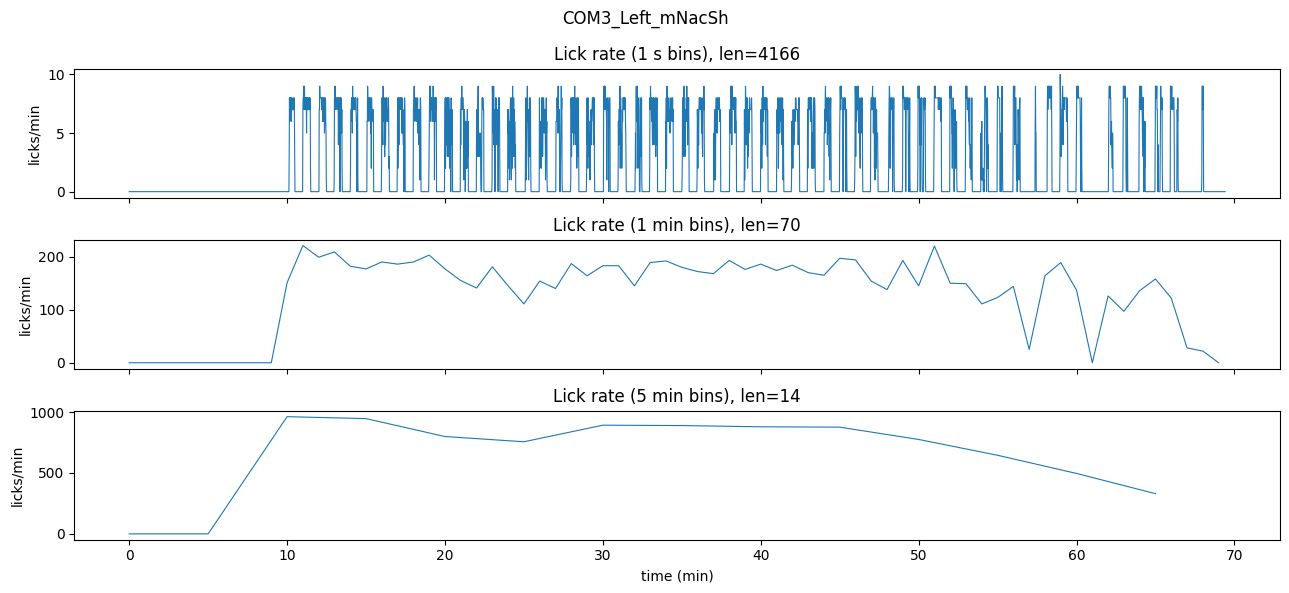

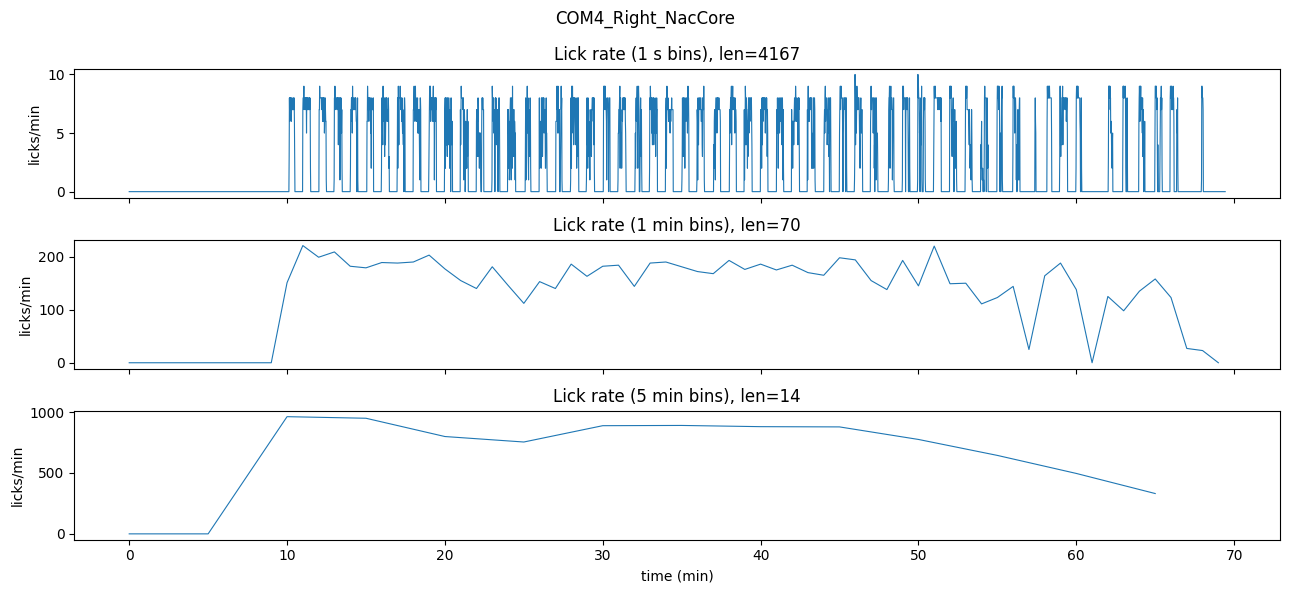

In [32]:
for side_data in data:
    burst_vars = side_data[BURST_KEY]
    fig, ax = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
    for axis, (rate_key, label, bin_min) in zip(ax, [("Lickrate_1s", "1 s", 1 / 60),
                                                     ("Lickrate_1m", "1 min", 1),
                                                     ("Lickrate_5m", "5 min", 5)]):
        rate = np.asarray(burst_vars[rate_key])
        axis.plot(np.arange(len(rate)) * bin_min, rate, lw=0.8)
        axis.set_ylabel("licks/min"); axis.set_title(f"Lick rate ({label} bins), len={len(rate)}")
    ax[-1].set_xlabel("time (min)"); fig.suptitle(side_data["Full_side_name"]); fig.tight_layout()

## 8. Bottle position & trial structure

`BottlePos` marks when the sucrose spout is available. Each access period is a 'trial' — the task is a baseline period followed by repeated access / no-access periods.

COM3_Left_mNacSh: 60 access periods | mean duration 30.0 s | BottleIn_frameNum 54001 (627.9 s)
COM4_Right_NacCore: 60 access periods | mean duration 30.0 s | BottleIn_frameNum 54002 (627.9 s)


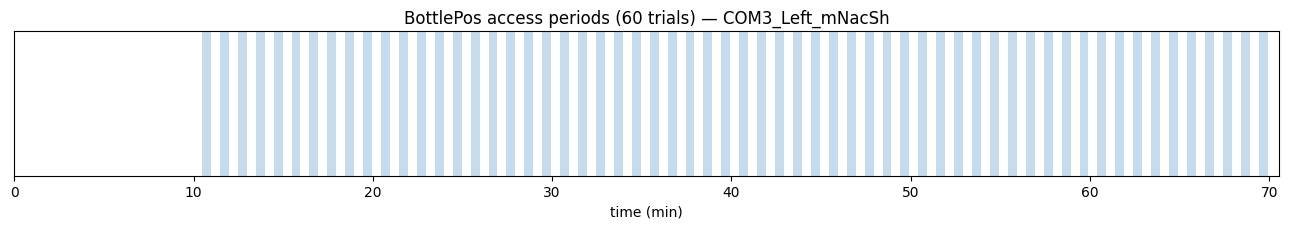

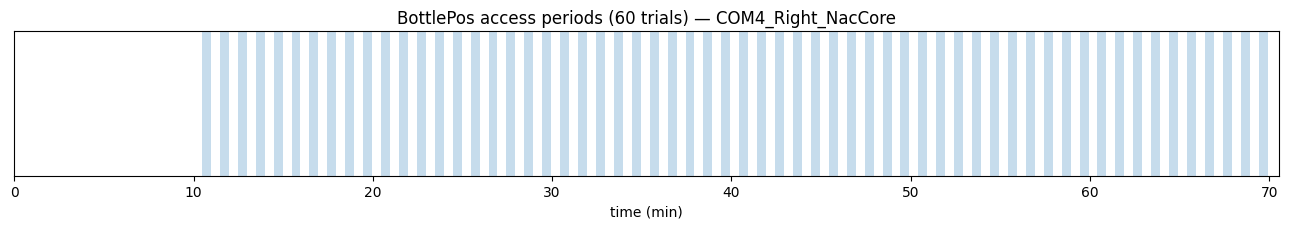

In [33]:
for side_data in data:
    fs = side_data["sampling_rate"]
    time_min = side_data["time"] / 1000 / 60
    bottle_in = np.nan_to_num(side_data["BottlePos"]) > 0.5
    access_starts = np.where(bottle_in[1:] & ~bottle_in[:-1])[0] + 1   # rising edges = spout in
    access_ends = np.where(~bottle_in[1:] & bottle_in[:-1])[0] + 1     # falling edges = spout out
    n_access = min(len(access_starts), len(access_ends))
    access_durations_s = (access_ends[:n_access] - access_starts[:n_access]) / fs
    print(f"{side_data['Full_side_name']}: {len(access_starts)} access periods | "
          f"mean duration {np.mean(access_durations_s):.1f} s | "
          f"BottleIn_frameNum {side_data['BottleIn_frameNum']} ({side_data['BottleIn_frameNum']/fs:.1f} s)")

    fig, ax = plt.subplots(figsize=(13, 2.4))
    for start_idx, end_idx in zip(access_starts[:n_access], access_ends[:n_access]):
        ax.axvspan(start_idx / fs / 60, end_idx / fs / 60, color="tab:blue", alpha=0.25, lw=0)
    ax.set_xlim(time_min[0], time_min[-1]); ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_title(f"BottlePos access periods ({len(access_starts)} trials) — {side_data['Full_side_name']}")
    ax.set_xlabel("time (min)")
    fig.tight_layout()

## 9. DLC tracking — head/nose-to-spout distances

DeepLabCut-derived **distances** (not raw x/y) plus likelihoods, interpolated to the photometry clock. `Cleaned_Head_Distance` is the jump-corrected, session-cropped version.

COM3_Left_mNacSh DLC keys: ['DLC_Distance_head_middle-spout', 'DLC_Likelihood_head_middle', 'DLC_Distance_nose-spout', 'DLC_Likelihood_nose', 'DLC_Distance_head_middle-nose']
COM4_Right_NacCore DLC keys: ['DLC_Distance_head_middle-spout', 'DLC_Likelihood_head_middle', 'DLC_Distance_nose-spout', 'DLC_Likelihood_nose', 'DLC_Distance_head_middle-nose']


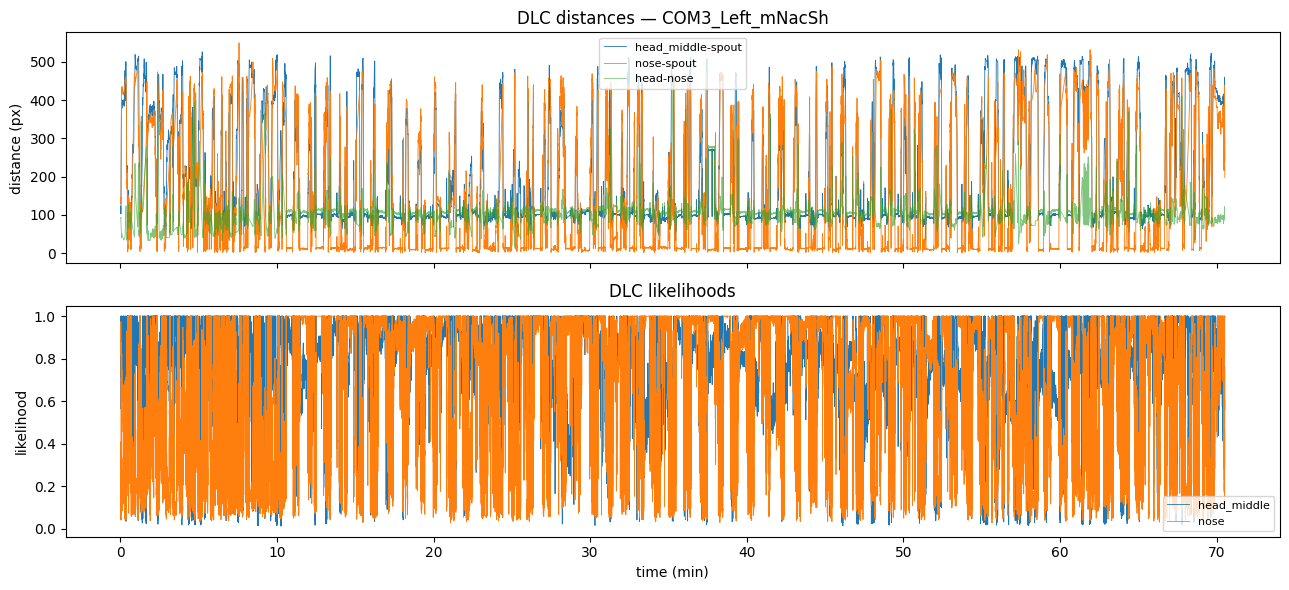

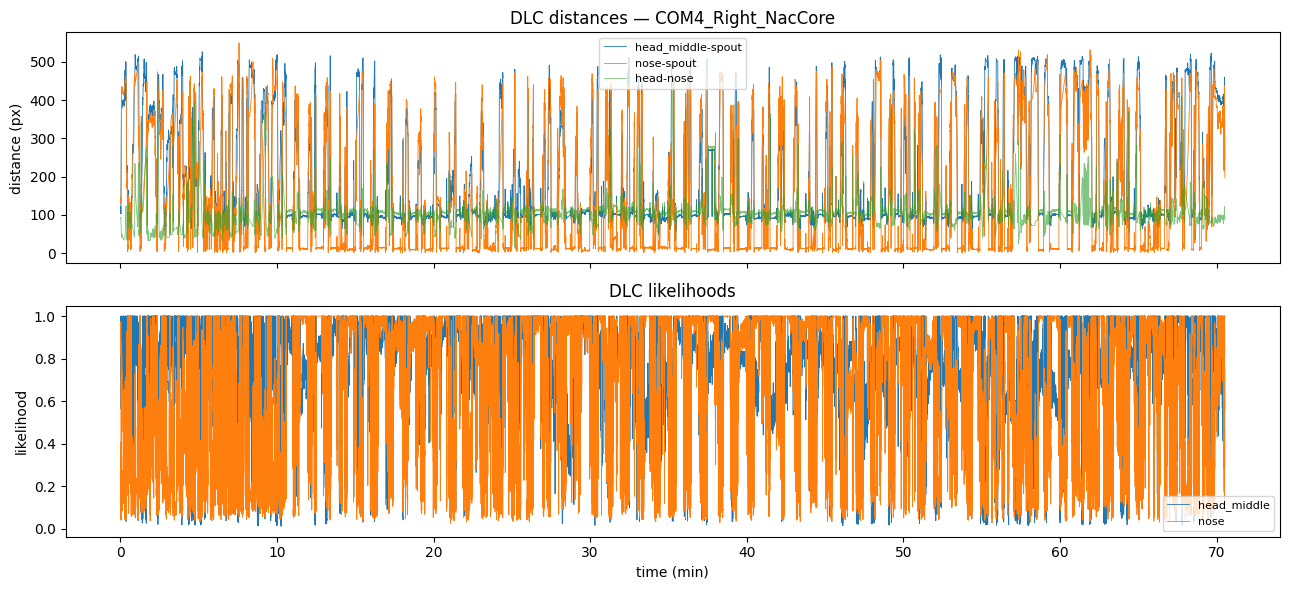

In [34]:
for side_data in data:
    time_min = side_data["time"] / 1000 / 60
    dlc_keys = [key for key in side_data if key.startswith("DLC_")]
    print(side_data["Full_side_name"], "DLC keys:", dlc_keys)

    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(time_min, side_data["DLC_Distance_head_middle-spout"], lw=0.6, label="head_middle-spout")
    ax[0].plot(time_min, side_data["DLC_Distance_nose-spout"], lw=0.6, label="nose-spout")
    ax[0].plot(time_min, side_data["DLC_Distance_head_middle-nose"], lw=0.6, label="head-nose", alpha=0.6)
    ax[0].set_ylabel("distance (px)"); ax[0].legend(fontsize=8)
    ax[0].set_title(f"DLC distances — {side_data['Full_side_name']}")
    ax[1].plot(time_min, side_data["DLC_Likelihood_head_middle"], lw=0.6, label="head_middle")
    ax[1].plot(time_min, side_data["DLC_Likelihood_nose"], lw=0.6, label="nose")
    ax[1].set_ylabel("likelihood"); ax[1].set_xlabel("time (min)"); ax[1].legend(fontsize=8); ax[1].set_title("DLC likelihoods")
    fig.tight_layout()

## 10. Engagement state vectors

Binary 'engaged with spout' vectors — an automatic threshold and several manual ones, for both head- and nose-based distance. The number in each key name is the distance threshold used.

  COM3_Left_mNacSh       Engagement_head_middle-spout_auto-274.64   engaged fraction = 0.703
  COM3_Left_mNacSh       Engagement_nose-spout_auto-399.99          engaged fraction = 0.874
  COM3_Left_mNacSh       Engagement_head_middle-spout_manual-85     engaged fraction = 0.068
  COM3_Left_mNacSh       Engagement_nose-spout_manual-15            engaged fraction = 0.389
  COM3_Left_mNacSh       Engagement_head_middle-spout_manual-100    engaged fraction = 0.368
  COM3_Left_mNacSh       Engagement_nose-spout_manual-30            engaged fraction = 0.439
  COM3_Left_mNacSh       Engagement_head_middle-spout_manual-150    engaged fraction = 0.572
  COM3_Left_mNacSh       Engagement_nose-spout_manual-80            engaged fraction = 0.514
  COM4_Right_NacCore     Engagement_head_middle-spout_auto-274.64   engaged fraction = 0.703
  COM4_Right_NacCore     Engagement_nose-spout_auto-399.99          engaged fraction = 0.874
  COM4_Right_NacCore     Engagement_head_middle-spout_manual-85     en

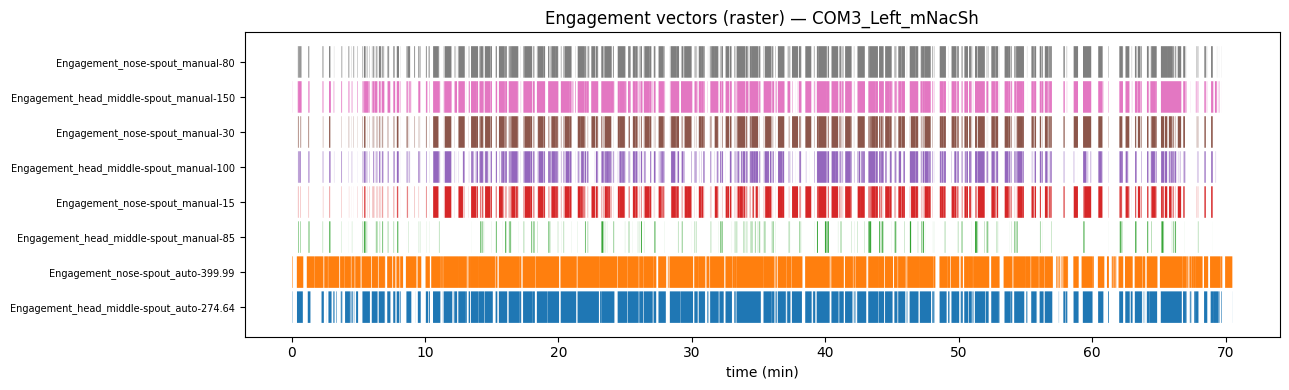

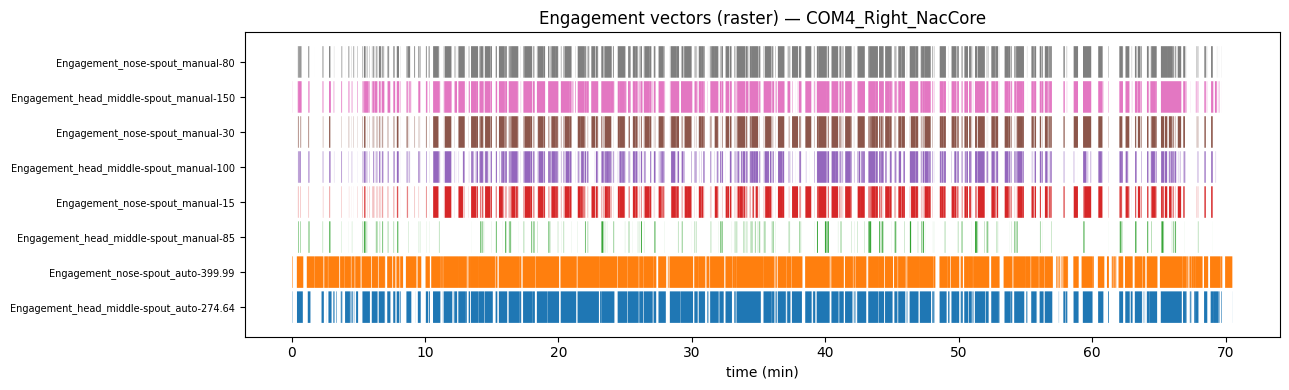

In [35]:
for side_data in data:
    time_min = side_data["time"] / 1000 / 60
    engagement_keys = [key for key in side_data if key.startswith("Engagement")]
    fig, ax = plt.subplots(figsize=(13, 4))
    for row, engagement_key in enumerate(engagement_keys):
        engaged_fraction = float(np.mean(side_data[engagement_key]))
        print(f"  {side_data['Full_side_name']:22s} {engagement_key:42s} engaged fraction = {engaged_fraction:.3f}")
        ax.fill_between(time_min, row, row + np.asarray(side_data[engagement_key]) * 0.9, step="mid", lw=0)
    ax.set_yticks(np.arange(len(engagement_keys)) + 0.45); ax.set_yticklabels(engagement_keys, fontsize=7)
    ax.set_xlabel("time (min)"); ax.set_title(f"Engagement vectors (raster) — {side_data['Full_side_name']}")
    fig.tight_layout()

## 11. Distance states & approach/leave events

`Distance_States_Events` discretizes the head-to-spout distance into states (near/transition/far) and marks approach and leave transition events. The detection parameters live in `QC['distance_states_transition_events']`.

COM3_Left_mNacSh: state unique [0 1 2] | #approach 18036 | #leave 45941
COM4_Right_NacCore: state unique [0 1 2] | #approach 18029 | #leave 45944

Detection settings (QC['distance_states_transition_events']):
    Time_of_saving       2026-04-06 15:04:50.694073
    distance_fs          30
    likelihood_thresh    0.8
    jump_thresh          150
    smooth_window        20
    interp_limit         800
    near_thresh          180
    far_tresh            300
    min_transition_s     0.5
    max_transition_s     15.0
    min_move             70
    lick_bout_ili_ms     1200
    lick_bout_pad_ms     200


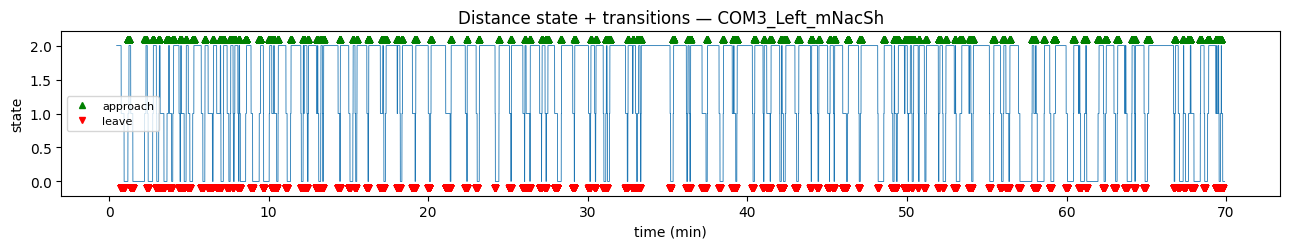

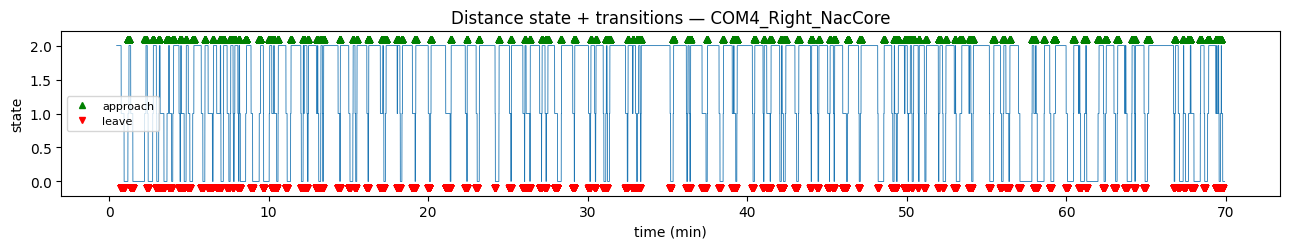

In [36]:
for side_data in data:
    fs = side_data["sampling_rate"]
    distance_states = side_data["Distance_States_Events"]
    print(f"{side_data['Full_side_name']}: state unique {np.unique(distance_states['state'])} | "
          f"#approach {int((distance_states['Approach_events'] > 0).sum())} | "
          f"#leave {int((distance_states['Leave_events'] > 0).sum())}")

    # session-cropped arrays begin at SessionStart_frameNum on the photometry clock
    state_time_min = (side_data["SessionStart_frameNum"] + np.arange(len(distance_states["state"]))) / fs / 60
    approach_times_min = state_time_min[distance_states["Approach_events"] > 0]
    leave_times_min = state_time_min[distance_states["Leave_events"] > 0]
    fig, ax = plt.subplots(figsize=(13, 2.6))
    ax.plot(state_time_min, distance_states["state"], lw=0.6)
    ax.plot(approach_times_min, np.full_like(approach_times_min, 2.1), "^", ms=4, color="g", label="approach")
    ax.plot(leave_times_min, np.full_like(leave_times_min, -0.1), "v", ms=4, color="r", label="leave")
    ax.set_xlabel("time (min)"); ax.set_ylabel("state"); ax.legend(fontsize=8)
    ax.set_title(f"Distance state + transitions — {side_data['Full_side_name']}")
    fig.tight_layout()

print("\nDetection settings (QC['distance_states_transition_events']):")
for key, value in data[0]["QC"]["distance_states_transition_events"].items():
    print(f"    {key:20s} {value}")

## 12. QC — Hampel outlier removal

Parameters and outcome of the Hampel filter applied to each analog channel.

COM3_Left_mNacSh
  params:        {'fs': 86.0, 'window_sec': 0.9, 'n_sigmas': 8.0, 'replace_with': 'median'}
  n_outliers:    {'analog_1': 0, 'analog_2': 0, 'analog_3': 67}
  frac_outliers: {'analog_1': 0.0, 'analog_2': 0.0, 'analog_3': 0.000184}
COM4_Right_NacCore
  params:        {'fs': 86.0, 'window_sec': 0.9, 'n_sigmas': 8.0, 'replace_with': 'median'}
  n_outliers:    {'analog_1': 0, 'analog_2': 1, 'analog_3': 85}
  frac_outliers: {'analog_1': 0.0, 'analog_2': 3e-06, 'analog_3': 0.000233}


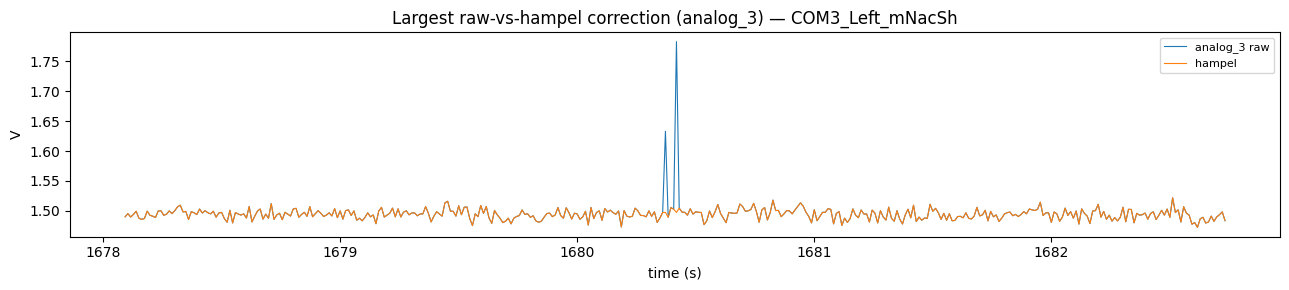

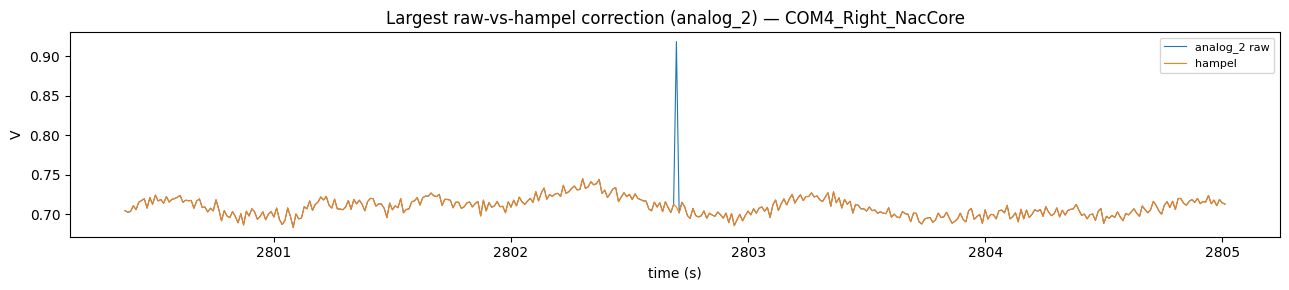

In [37]:
for side_data in data:
    hampel_qc = side_data["QC"]["hampel"]
    print(side_data["Full_side_name"])
    print("  params:       ", {k: v for k, v in hampel_qc.items() if not isinstance(v, dict)})
    print("  n_outliers:   ", hampel_qc["n_outliers"])
    print("  frac_outliers:", {k: round(v, 6) for k, v in hampel_qc["frac_outliers"].items()})

    # Find the channel + sample where the Hampel filter made the largest correction
    worst_channel, worst_idx, worst_correction = None, 0, -1.0
    for raw_key in ("analog_1", "analog_2", "analog_3"):
        hampel_key = f"analog{raw_key[-1]}_hampel"
        correction = np.abs(side_data[raw_key] - side_data[hampel_key])
        peak_idx = int(np.argmax(correction))
        if correction[peak_idx] > worst_correction:
            worst_channel, worst_idx, worst_correction = raw_key, peak_idx, correction[peak_idx]

    start_idx, end_idx = max(0, worst_idx - 200), worst_idx + 200
    hampel_key = f"analog{worst_channel[-1]}_hampel"
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(side_data["time"][start_idx:end_idx] / 1000, side_data[worst_channel][start_idx:end_idx], label=f"{worst_channel} raw", lw=0.8)
    ax.plot(side_data["time"][start_idx:end_idx] / 1000, side_data[hampel_key][start_idx:end_idx], label="hampel", lw=0.8)
    ax.set_title(f"Largest raw-vs-hampel correction ({worst_channel}) — {side_data['Full_side_name']}")
    ax.set_xlabel("time (s)"); ax.set_ylabel("V"); ax.legend(fontsize=8); fig.tight_layout()

## 13. Wall-clock timing & frame markers

How the session sits in real time, and the key frame indices on the photometry clock.

In [38]:
for side_data in data:
    fs = side_data["sampling_rate"]
    print("=" * 70, "\n", side_data["Full_side_name"])
    print("  date_time (start):", side_data["date_time"], "| end_time:", side_data["end_time"])
    print("  Abs_Time:         ", side_data["Abs_Time"].iloc[0], "->", side_data["Abs_Time"].iloc[-1])
    print("  ms_since_midnight:", int(side_data["ms_since_midnight"].iloc[0]), "->", int(side_data["ms_since_midnight"].iloc[-1]))
    for frame_key in ["BottleIn_frameNum", "SessionStart_frameNum", "SessionEnd_frameNum"]:
        frame = side_data[frame_key]
        print(f"    {frame_key:22s} {frame:>8d}  ({frame/fs:7.1f} s, {frame/fs/60:5.2f} min)")
    n_samples = len(side_data["analog_1"])
    print(f"    {'total samples':22s} {n_samples:>8d}  ({n_samples/fs/60:5.2f} min)")

 COM3_Left_mNacSh
  date_time (start): 2025-11-06 09:31:35.090000 | end_time: 2025-11-06T10:42:08.163
  Abs_Time:          2025-11-06 09:31:35.090000 -> 2025-11-06 10:42:08.124883721
  ms_since_midnight: 34295090 -> 38528124
    BottleIn_frameNum         54001  (  627.9 s, 10.47 min)
    SessionStart_frameNum      2451  (   28.5 s,  0.47 min)
    SessionEnd_frameNum      360724  ( 4194.5 s, 69.91 min)
    total samples            364042  (70.55 min)
 COM4_Right_NacCore
  date_time (start): 2025-11-06 09:31:35.096000 | end_time: 2025-11-06T10:42:08.275
  Abs_Time:          2025-11-06 09:31:35.096000 -> 2025-11-06 10:42:08.189023256
  ms_since_midnight: 34295096 -> 38528189
    BottleIn_frameNum         54002  (  627.9 s, 10.47 min)
    SessionStart_frameNum      2452  (   28.5 s,  0.48 min)
    SessionEnd_frameNum      360729  ( 4194.5 s, 69.91 min)
    total samples            364047  (70.55 min)


## 14. Combined session overview

Everything aligned on the session clock — a 5 min window mid-session showing how photometry, licking, bottle availability, engagement and distance state line up.

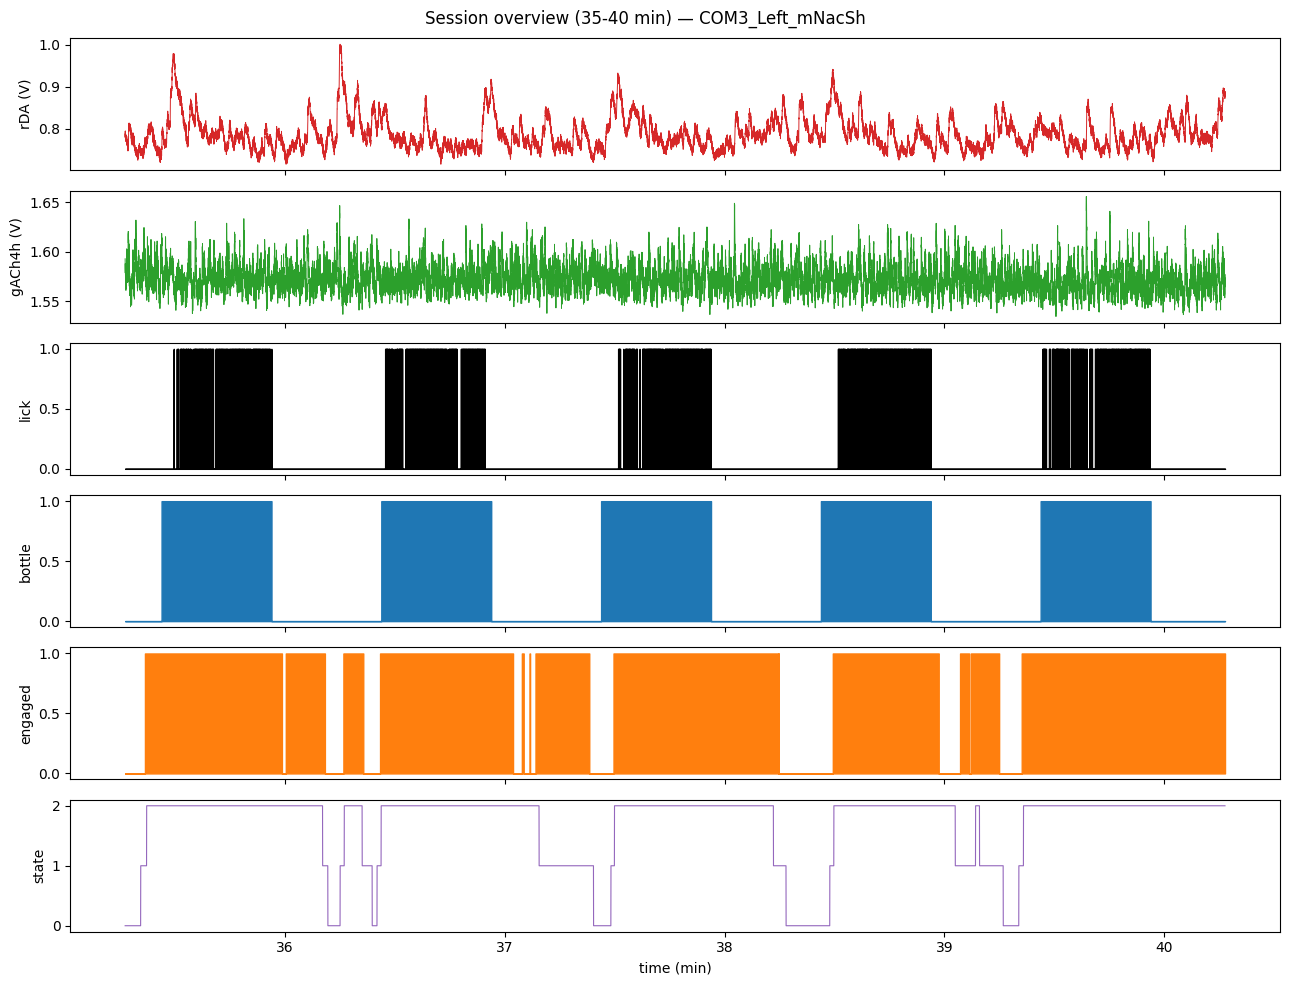

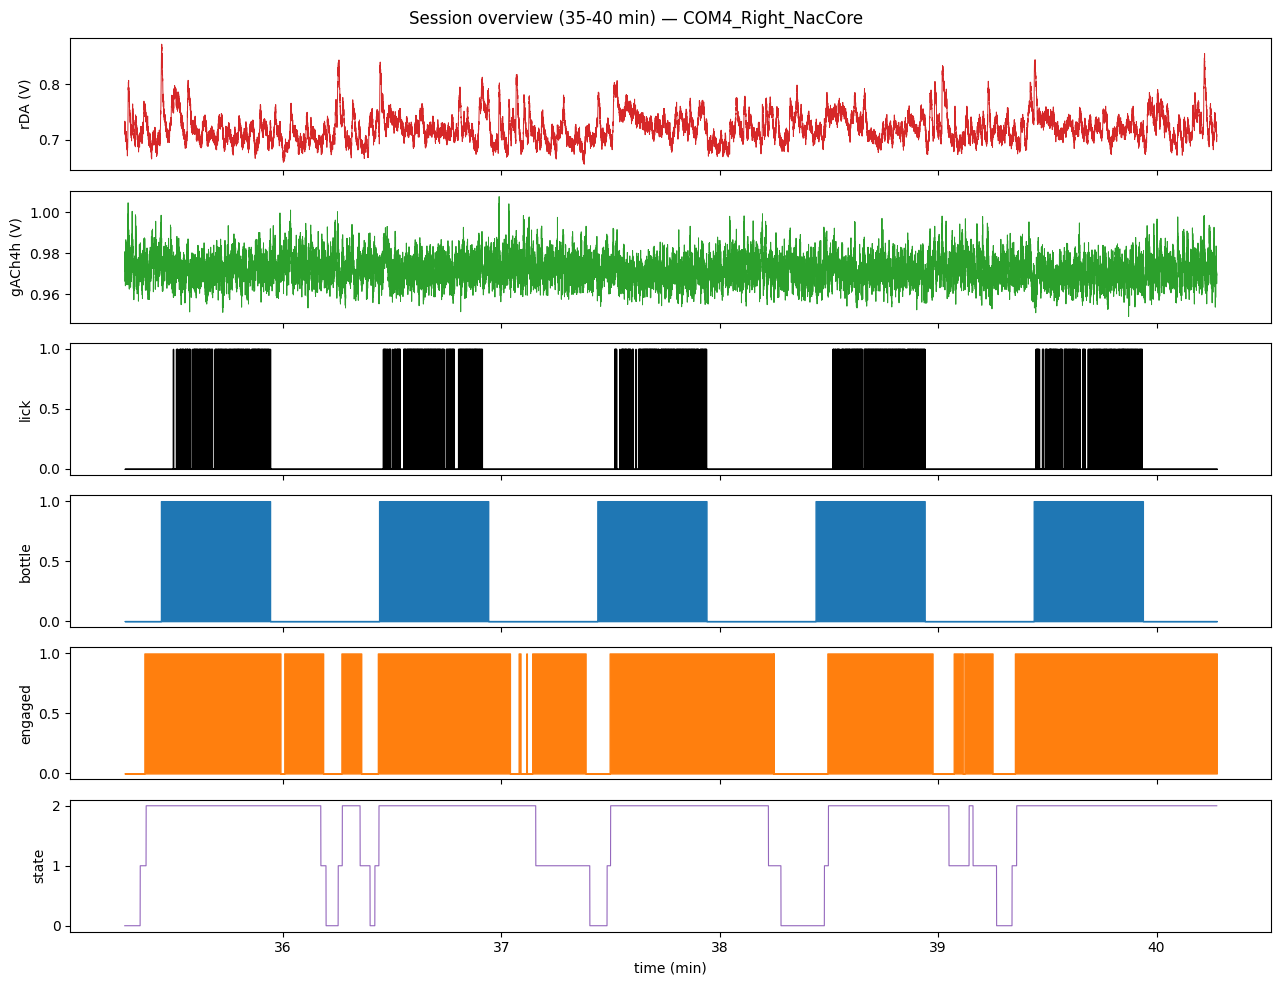

In [39]:
for side_data in data:
    fs = side_data["sampling_rate"]
    time_min = side_data["time"] / 1000 / 60
    distance_states = side_data["Distance_States_Events"]
    state_time_min = (side_data["SessionStart_frameNum"] + np.arange(len(distance_states["state"]))) / fs / 60
    auto_engagement_key = [key for key in side_data
                           if key.startswith("Engagement") and "auto" in key and "head" in key][0]

    window_start_min = time_min[-1] / 2                       # 5 min window centered mid-session
    window_end_min = min(window_start_min + 5, time_min[-1])
    in_window = (time_min >= window_start_min) & (time_min <= window_end_min)
    state_in_window = (state_time_min >= window_start_min) & (state_time_min <= window_end_min)

    fig, ax = plt.subplots(6, 1, figsize=(13, 10), sharex=True)
    ax[0].plot(time_min[in_window], side_data["analog2_hampel"][in_window], color="#D62728", lw=0.7); ax[0].set_ylabel("rDA (V)")
    ax[1].plot(time_min[in_window], side_data["analog1_hampel"][in_window], color="#2CA02C", lw=0.7); ax[1].set_ylabel("gACh4h (V)")
    ax[2].fill_between(time_min[in_window], 0, np.nan_to_num(side_data["LickBinary_2.3"])[in_window], step="mid", color="k"); ax[2].set_ylabel("lick")
    ax[3].fill_between(time_min[in_window], 0, np.nan_to_num(side_data["BottlePos"])[in_window], step="mid", color="tab:blue"); ax[3].set_ylabel("bottle")
    ax[4].fill_between(time_min[in_window], 0, side_data[auto_engagement_key][in_window], step="mid", color="tab:orange"); ax[4].set_ylabel("engaged")
    ax[5].plot(state_time_min[state_in_window], distance_states["state"][state_in_window], lw=0.8, color="tab:purple"); ax[5].set_ylabel("state")
    ax[5].set_xlabel("time (min)")
    fig.suptitle(f"Session overview ({window_start_min:.0f}-{window_end_min:.0f} min) — {side_data['Full_side_name']}")
    fig.tight_layout()

## 15. Compare the two sides side-by-side

In [40]:
summary_rows = []
for index, side_data in enumerate(data):
    burst_vars = side_data[BURST_KEY]
    summary_rows.append({
        "index": index,
        "side": side_data["Full_side_name"],
        "filename": side_data["filename"],
        "n_samples": len(side_data["analog_1"]),
        "grams_consumed": side_data["GramConsumed"],
        "num_licks": burst_vars["NumLicks"],
        "num_bursts": burst_vars["NumBursts"],
        "session_start_frame": side_data["SessionStart_frameNum"],
        "session_end_frame": side_data["SessionEnd_frameNum"],
    })
pd.DataFrame(summary_rows).set_index("index")

,side,filename,n_samples,grams_consumed,num_licks,num_bursts,session_start_frame,session_end_frame
index,,,,,,,,
0,COM3_Left_mNacSh,IM1923_Trial-SF5-Sucrose_COM3_-2025-11-06-093135.ppd,364042,81.82,9245,74,2451,360724
1,COM4_Right_NacCore,IM1923_Trial-SF5-Sucrose_COM4_-2025-11-06-093135.ppd,364047,81.82,9246,74,2452,360729
